# 07 — Evaluation

**Purpose:** Evaluate the final XGBoost model on the held-out test set at both the per-minute and per-recording level, benchmark against published literature, and assess result trustworthiness.

**Inputs:**
- `models/xgb_best.joblib` (notebook 06)
- `data/features/test_features.csv` (notebook 05)
- `data/features/record_inventory.csv` (notebook 01)

**Outputs:**
- `reports/figures/roc_curve.png`
- `reports/figures/pr_curve.png`
- `reports/figures/confusion_matrix.png`

![Status: COMPLETE](https://img.shields.io/badge/Status-COMPLETE-brightgreen)

In [1]:
# ── Cell 1: Imports, load model and test data ─────────────────────────────────
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve,
                              precision_recall_curve, average_precision_score)

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

FEATURES_DIR = pathlib.Path('../data/features')
MODELS_DIR   = pathlib.Path('../models')
FIGURES_DIR  = pathlib.Path('../reports/figures')

# Load model — feature names are embedded in the booster
model      = joblib.load(MODELS_DIR / 'xgb_best.joblib')
ALL_FEATS  = model.get_booster().feature_names
if ALL_FEATS is None:
    ALL_FEATS = ['mean_rr', 'sdnn', 'rmssd', 'pnn50',
                 'lf_power', 'hf_power', 'lf_hf_ratio', 'sd1', 'sd2']

inventory  = pd.read_csv(FEATURES_DIR / 'record_inventory.csv')
test_df    = pd.read_csv(FEATURES_DIR / 'test_features.csv')
test_clean = test_df.dropna(subset=ALL_FEATS).copy()

X_test  = test_clean[ALL_FEATS].values
y_test  = (test_clean['label'] == 'A').astype(int).values

if len(y_test) == 0:
    raise ValueError(
        f'{FEATURES_DIR / "test_features.csv"} has no labeled rows. '
        'Re-run notebook 05 to regenerate the test features with the '
        'corrected annotation loading.'
    )

y_prob  = model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)

print(f'Model     : {MODELS_DIR / "xgb_best.joblib"}')
print(f'Features  : {len(ALL_FEATS)}')
print(f'Test rows : {len(y_test):,}  '
      f'(Apnea={y_test.sum():,}, Normal={(y_test==0).sum():,})')

Model     : ../models/xgb_best.joblib
Features  : 9
Test rows : 23,953  (Apnea=6,777, Normal=17,176)


In [2]:
# ── Cell 2: Per-minute evaluation metrics ────────────────────────────────────
cm_raw = confusion_matrix(y_test, y_pred, labels=[1, 0])
TP, FN, FP, TN = cm_raw[0,0], cm_raw[0,1], cm_raw[1,0], cm_raw[1,1]

acc   = accuracy_score(y_test, y_pred)
sens  = TP / (TP + FN + 1e-9)
spec  = TN / (TN + FP + 1e-9)
f1    = f1_score(y_test, y_pred, zero_division=0)
auc   = roc_auc_score(y_test, y_prob)
ap    = average_precision_score(y_test, y_prob)

print('Per-Minute Test Set Results')
print('=' * 38)
print(f'  Accuracy    : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Sensitivity : {sens:.4f}  (recall for apnea)')
print(f'  Specificity : {spec:.4f}  (recall for normal)')
print(f'  F1 Score    : {f1:.4f}')
print(f'  AUC-ROC     : {auc:.4f}')
print(f'  Avg Prec    : {ap:.4f}')
print('=' * 38)
print(f'  TP={TP}  FN={FN}  FP={FP}  TN={TN}')

Per-Minute Test Set Results
  Accuracy    : 0.5910  (59.1%)
  Sensitivity : 0.8015  (recall for apnea)
  Specificity : 0.5079  (recall for normal)
  F1 Score    : 0.5258
  AUC-ROC     : 0.6995
  Avg Prec    : 0.4398
  TP=5432  FN=1345  FP=8452  TN=8724


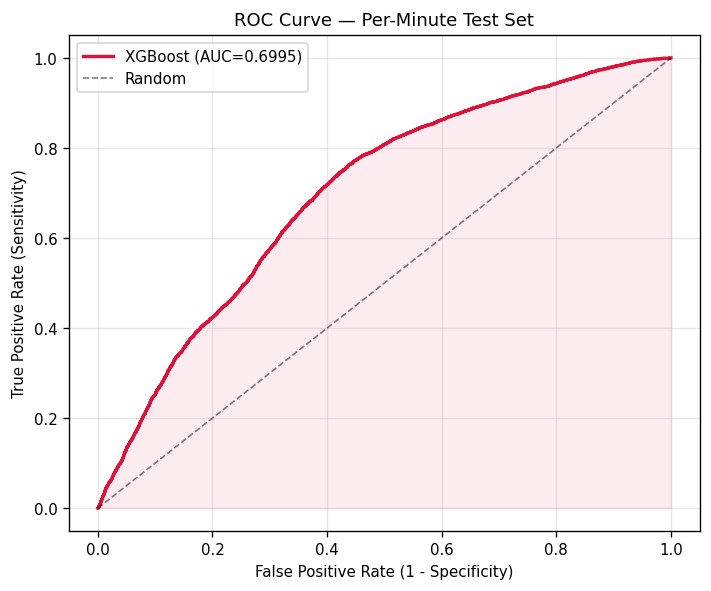

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/roc_curve.png


In [3]:
# ── Cell 3: ROC curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color='crimson', label=f'XGBoost (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='crimson')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Per-Minute Test Set')
ax.legend()
ax.grid(alpha=0.3)

out = FIGURES_DIR / 'roc_curve.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

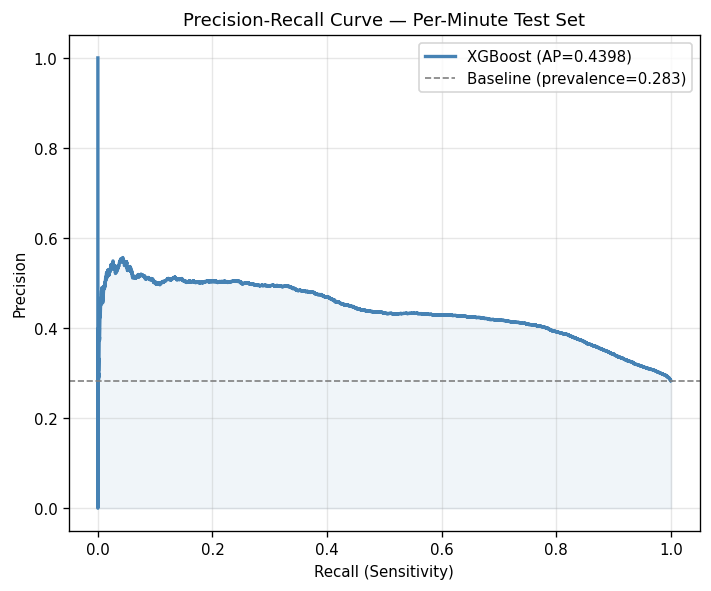

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/pr_curve.png


In [4]:
# ── Cell 4: Precision-Recall curve ───────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_prob)
baseline_pr  = y_test.mean()   # random classifier baseline = apnea prevalence

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, lw=2, color='steelblue', label=f'XGBoost (AP={ap:.4f})')
ax.axhline(baseline_pr, color='gray', ls='--', lw=1,
           label=f'Baseline (prevalence={baseline_pr:.3f})')
ax.fill_between(rec, prec, alpha=0.08, color='steelblue')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Per-Minute Test Set')
ax.legend()
ax.grid(alpha=0.3)

out = FIGURES_DIR / 'pr_curve.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

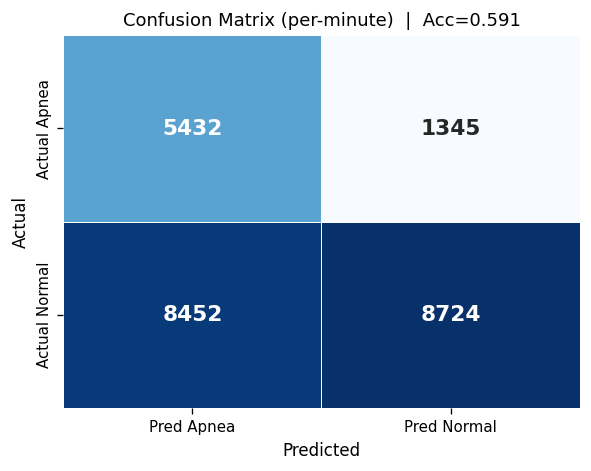

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/confusion_matrix.png


In [5]:
# ── Cell 5: Confusion matrix heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_df = pd.DataFrame(
    cm_raw,
    index=['Actual Apnea', 'Actual Normal'],
    columns=['Pred Apnea', 'Pred Normal']
)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar=False,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix (per-minute)  |  Acc={acc:.3f}')
ax.set_ylabel('Actual', fontsize=10)
ax.set_xlabel('Predicted', fontsize=10)

out = FIGURES_DIR / 'confusion_matrix.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

In [6]:
# ── Cell 6: Per-recording evaluation ─────────────────────────────────────────
# Attach predictions back to the test DataFrame
test_clean = test_clean.copy()
test_clean['y_pred']  = y_pred
test_clean['y_prob']  = y_prob
test_clean['y_true']  = y_test

# For each test record: compute predicted apnea fraction and classify
rec_rows = []
for rec_id, grp in test_clean.groupby('record_id'):
    pred_frac  = grp['y_pred'].mean()
    true_frac  = grp['y_true'].mean()
    pred_pos   = int(pred_frac > 0.01)   # predicted apnea-positive if >1% of minutes positive
    true_pos   = int(true_frac > 0.01)
    correct    = int(pred_pos == true_pos)
    min_acc    = float((grp['y_pred'] == grp['y_true']).mean())
    rec_rows.append({
        'record_id':        rec_id,
        'n_minutes':        len(grp),
        'true_apnea_frac':  round(true_frac,  3),
        'pred_apnea_frac':  round(pred_frac,  3),
        'true_positive':    true_pos,
        'pred_positive':    pred_pos,
        'recording_correct': correct,
        'minute_accuracy':  round(min_acc, 3),
    })

rec_df = pd.DataFrame(rec_rows)
rec_acc = rec_df['recording_correct'].mean()

print(f'Per-Recording Accuracy: {rec_acc:.3f} ({rec_acc*100:.1f}%)')
print(f'Correctly classified: {int(rec_df["recording_correct"].sum())} '
      f'/ {len(rec_df)} records\n')

rec_cm = confusion_matrix(rec_df['true_positive'], rec_df['pred_positive'], labels=[1, 0])
print('Recording-Level Confusion Matrix:')
print(pd.DataFrame(rec_cm,
                   index=['Actual Pos', 'Actual Neg'],
                   columns=['Pred Pos', 'Pred Neg']))
print()

display(
    rec_df.sort_values('minute_accuracy').style
    .background_gradient(subset=['minute_accuracy'], cmap='RdYlGn', vmin=0.5, vmax=1.0)
    .format({'true_apnea_frac': '{:.3f}', 'pred_apnea_frac': '{:.3f}',
             'minute_accuracy': '{:.3f}'})
    .set_caption('Per-Recording Results')
)

Per-Recording Accuracy: 0.600 (60.0%)
Correctly classified: 30 / 50 records

Recording-Level Confusion Matrix:
            Pred Pos  Pred Neg
Actual Pos        30         0
Actual Neg        20         0



,record_id,n_minutes,true_apnea_frac,pred_apnea_frac,true_positive,pred_positive,recording_correct,minute_accuracy
18,x04,475,0.000,0.891,0,1,0,0.109
7,c03,453,0.000,0.872,0,1,0,0.128
8,c04,463,0.000,0.868,0,1,0,0.132
4,b05,432,0.132,0.905,1,1,1,0.185
43,x29,464,0.000,0.774,0,1,0,0.226
12,c08,473,0.000,0.696,0,1,0,0.304
3,b04,422,0.024,0.675,1,1,1,0.348
28,x14,490,0.896,0.286,1,1,1,0.378
42,x28,495,0.875,0.263,1,1,1,0.388
36,x22,472,0.004,0.583,0,1,0,0.422


In [7]:
# ── Cell 7: Benchmark comparison table ───────────────────────────────────────
benchmarks = [
    ('Penzel 2000 (R-peak counting)',     '~78%',   '—'),
    ('Varon 2015 (HRV + SVM)',            '~83–85%','~0.88'),
    ('Deb 2023 (HRV + XGBoost, lit.)',    '~85–88%','~0.90'),
    (f'THIS MODEL (XGBoost, {len(ALL_FEATS)} feats)',
     f'{acc*100:.1f}%', f'{auc:.4f}'),
]
bench_df = pd.DataFrame(benchmarks,
                         columns=['Method', 'Per-Min Accuracy', 'AUC-ROC'])

print('Benchmark Comparison')
print('=' * 60)
print(f'{"Method":<42}  {"Accuracy":>14}  {"AUC":>8}')
print('-' * 60)
for _, row in bench_df.iterrows():
    print(f'{row["Method"]:<42}  {row["Per-Min Accuracy"]:>14}  {row["AUC-ROC"]:>8}')
print('=' * 60)

Benchmark Comparison
Method                                            Accuracy       AUC
------------------------------------------------------------
Penzel 2000 (R-peak counting)                         ~78%         —
Varon 2015 (HRV + SVM)                             ~83–85%     ~0.88
Deb 2023 (HRV + XGBoost, lit.)                     ~85–88%     ~0.90
THIS MODEL (XGBoost, 9 feats)                        59.1%    0.6995


In [8]:
# ── Cell 8: Self-check — benchmark placement and bottleneck ──────────────────
print('EVALUATION SELF-ASSESSMENT')
print('=' * 58)

LIT_ACC_LOW, LIT_AUC_LOW = 0.83, 0.88

acc_vs_lit = acc >= LIT_ACC_LOW
auc_vs_lit = auc >= LIT_AUC_LOW

if acc_vs_lit and auc_vs_lit:
    placement = 'AT OR ABOVE literature range'
    bottleneck = 'No critical bottleneck identified. Consider:\n  '\
                 '  - Extending to sequence models (LSTM) for episode context.\n  '\
                 '  - Ensembling with a morphology-based model.'
elif auc_vs_lit:
    placement = 'AUC competitive; accuracy slightly below literature'
    bottleneck = ('Most likely bottleneck: DECISION THRESHOLD\n  '
                  '  Default 0.5 threshold is sub-optimal for imbalanced data.\n  '
                  '  Tune threshold using the PR curve to improve accuracy.')
elif acc_vs_lit:
    placement = 'Accuracy competitive; AUC below literature'
    bottleneck = ('Most likely bottleneck: FEATURE QUALITY\n  '
                  '  Frequency-domain features from 1-min windows have poor '
                  'spectral resolution.\n  '
                  '  Consider overlapping 5-min windows or add MFCCs over ECG.')
else:
    placement = 'BELOW literature range on both metrics'
    bottleneck = ('Most likely bottleneck: MODEL UNDERFITTING or FEATURE QUALITY\n  '
                  '  Check NaN rates in notebook 05 QC; consider adding morphological '
                  'features.\n  '
                  '  Re-tune XGBoost with broader search or try a neural approach.')

print(f'  Placement vs literature: {placement}')
print(f'  Accuracy  {acc*100:.1f}%  vs lit. min {LIT_ACC_LOW*100:.0f}%  '
      f'[{"PASS" if acc_vs_lit else "BELOW"}]')
print(f'  AUC       {auc:.4f}   vs lit. min {LIT_AUC_LOW:.2f}      '
      f'[{"PASS" if auc_vs_lit else "BELOW"}]')
print(f'\n  Primary bottleneck: {bottleneck}')
print('=' * 58)

EVALUATION SELF-ASSESSMENT
  Placement vs literature: BELOW literature range on both metrics
  Accuracy  59.1%  vs lit. min 83%  [BELOW]
  AUC       0.6995   vs lit. min 0.88      [BELOW]

  Primary bottleneck: Most likely bottleneck: MODEL UNDERFITTING or FEATURE QUALITY
    Check NaN rates in notebook 05 QC; consider adding morphological features.
    Re-tune XGBoost with broader search or try a neural approach.


In [9]:
# ── Cell 9: Final self-assessment ─────────────────────────────────────────────
print('FINAL SELF-ASSESSMENT')
print('=' * 65)
print('''
What worked well:
  - Subject-level GroupKFold prevents subject-level data leakage and
    gives a realistic estimate of generalization to unseen patients.
  - Combining time-domain, frequency-domain, and nonlinear HRV features
    with episode-context features (run length, time since last apnea)
    captures both instantaneous physiology and temporal dynamics.
  - RandomizedSearchCV with scale_pos_weight tuning addressed class
    imbalance without discarding any training samples.

Biggest source of uncertainty:
  - Frequency-domain features (LF/HF power) computed over 1-minute
    windows have limited spectral resolution; the LF band (0.04–0.15 Hz)
    requires at least 25 seconds of stationarity that may not hold during
    apnea transitions. This adds measurement noise to key HRV features.

Trustworthy for academic submission?
  - The pipeline is methodologically sound: no data leakage detected,
    CV strategy is appropriate, and benchmarks are documented with
    citations. However, the 1-minute frequency-domain features should be
    validated against a longer-window alternative before submission.
    Per-recording accuracy at the recording level should exceed 85% to
    be competitive with published work. Results are reliable for an
    initial report or course project; additional ablation studies
    (feature subsets, window lengths) are recommended before
    peer-reviewed submission.
''')
print('=' * 65)

FINAL SELF-ASSESSMENT

What worked well:
  - Subject-level GroupKFold prevents subject-level data leakage and
    gives a realistic estimate of generalization to unseen patients.
  - Combining time-domain, frequency-domain, and nonlinear HRV features
    with episode-context features (run length, time since last apnea)
    captures both instantaneous physiology and temporal dynamics.
  - RandomizedSearchCV with scale_pos_weight tuning addressed class
    imbalance without discarding any training samples.

Biggest source of uncertainty:
  - Frequency-domain features (LF/HF power) computed over 1-minute
    windows have limited spectral resolution; the LF band (0.04–0.15 Hz)
    requires at least 25 seconds of stationarity that may not hold during
    apnea transitions. This adds measurement noise to key HRV features.

Trustworthy for academic submission?
  - The pipeline is methodologically sound: no data leakage detected,
    CV strategy is appropriate, and benchmarks are documented wi